# Beige-Book-Tone — a quantitative teardown 🔬
### Event-window drift by tone · Welch *t* + placebo null · a Newey-West tone→drift regression · the regime (beta) confound · a costed event overlay · a synthetic planted-edge control

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Anecdote_leads_the_tape%3F: Not_supported](https://img.shields.io/badge/Anecdote_leads_the_tape%3F-Not_supported-8b949e?style=flat-square)

The deep companion to the [notebook for the curious](01_for_the_curious.ipynb). The believers fuse two claims: that a positive-tone Beige Book (1) **predicts** higher forward equity returns and (2) does so **early** enough to trade. We separate them. The conditional drift is the *right sign but insignificant* at every horizon; the decisive object is the **regime confound** — the apparent edge is cheerful books clustering in expansions, and it dissolves once the 2020 crash is removed. A costed overlay that captures almost nothing seals Tradability.

> ⚠️ **Proxy note (named on the Signal axis).** The tone is a **labelled LM-net-tone proxy** — a small hardcoded reconstruction, **not** a live full-text dictionary count (that scrape is the beat-7 extension). Because the proxy is our construction, we can't *certify* magnitude either way — but the null it produces is corroborated by the regime confound and the microstructure logic, and a synthetic control proves the engine would light up on a real link. Release dates are the real Beige-Book Wednesdays; SPY is yfinance daily total-return adjusted close, entered at the release-day close (no look-ahead). Methods in [`docs/references.md`](../docs/references.md), numbers in [`docs/results.md`](../docs/results.md).
>
> 💡 **The `💡 In plain words` notes** translate each result back to intuition.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from beige_book_tone import data, strategy as st

HAVE_REAL = data.have_real()
REL, SPY = data.load_real() if HAVE_REAL else (None, None)
print("SPY cache present:", HAVE_REAL,
      "| Beige-Book releases:", (0 if REL is None else len(REL)),
      "| positive-tone:", (0 if REL is None else int((REL['tone'] > 0).sum())))

# frozen headline numbers (mirror of docs/results.md)
R = {'start_rel': '2011-01-19', 'end_rel': '2024-12-04', 'n_events': 112, 'n_pos': 79, 'n_neg': 33, 'years': 13.9, 'spy_start': '2010-10-01', 'spy_end': '2024-12-31', 'spy_rows': 3586, 'fp_spy': 'eee0fc4ac90e', 'fp_rel': 'dd4d39f56f19', 'h1': (1, 79, 0.051, -0.401, -0.082, 51, 48, 1.13, 0.097), 'h3': (3, 79, 0.239, -0.552, 0.006, 61, 59, 0.95, 0.169), 'h5': (5, 79, 0.4, -0.834, 0.036, 68, 64, 1.16, 0.089), 'h10': (10, 79, 0.801, -1.148, 0.227, 67, 61, 1.44, 0.058), 'reg': {1: (0.2705, 1.46, 2.03, 0.138), 3: (0.0606, 0.14, 0.14, 0.013), 5: (0.3791, 0.77, 0.93, 0.073), 10: (0.7233, 1.05, 1.3, 0.1)}, 'overlay': (0.4, 0.38, 0.036, 0.21, 79, 5.7, 2.2, 14.2), 'robust': [('thr>0', 79, 0.4, 0.036, 1.16, 0.089), ('thr>median', 53, 0.548, 0.036, 1.45, 0.057), ('ex-2020', 78, 0.391, 0.184, 0.69, 0.195)], 'corr_prior': -0.238, 'syn': [(0.0, 62, 0.178, 0.335, -0.45, -0.311, -1.43), (0.004, 62, 1.815, 0.516, 3.16, 1.699, 7.84)]}


SPY cache present: True | Beige-Book releases: 112 | positive-tone: 79


## Verdict, up front

| Axis | Stamp | Decisive number |
|---|---|---|
| **Signal** | `NONE` | 5-day positive-tone mean **+0.40%** vs base **+0.04%** (right sign); best Welch **t = 1.44** (10d), placebo **p = 0.06** — no horizon clears **t ≥ 2**. |
| **Tradability** | `MIRAGE` | Long-the-window overlay **+2.2%/yr** net vs buy-hold **+14.2%/yr** — in cash ~90% of the time (79 trades). |
| **Anecdote leads the tape?** | `NOT SUPPORTED` | Drop 2020 and the positive-minus-base gap falls from **+0.36pp** to **+0.21pp** (t **0.69**); corr(tone, *prior* 5-day return) = **-0.24**. Regime, not lead. |

> 💡 In plain words: the equity market *is* a leading indicator of the economy, so a text that *describes* the economy need not lead the price. The Beige Book's cheerful books sit in expansions (positive drift) and its gloomy books sit in crashes (negative drift) — sampling the risk premium on a schedule, not forecasting it.

## 1 · The claim, steelmanned

Let $s_i$ be the Loughran-McDonald net tone of Beige Book $i$, $s = (\#\text{pos} - \#\text{neg})/(\#\text{pos} + \#\text{neg})$, z-scaled. A book is **POSITIVE** when $s_i > 0$. Entering at the **release-day close** $c_{t_0}$ (the book is public by then — no look-ahead), define the $H$-day forward drift $r_{i,H} = c_{t_0+H}/c_{t_0} - 1$.

- **H₁ (predicts).** $\mathbb{E}[r_H \mid s>0] > \mathbb{E}[r_H]$ — positive excess drift.
- **H₂ (dose-response).** In $r_H = a + b\,s + \varepsilon$, $b>0$ with HAC $|t|\ge 2$.
- **H₃ (leads, not regime).** The excess survives dropping the 2020 crash and isn't just cheerful books living in bull markets.

We find **H₁ directionally true but insignificant** (best Welch $t=1.44$), **H₂ rejected** ($b$'s HAC $t$ clears 2 at *only* the 1-day horizon and collapses to 0.1 at 3 days — an isolated crossing, not a dose-response), **H₃ rejected** (ex-2020 the gap and $t$ both shrink toward zero). The lore is right where it's uninformative (tone tracks the cycle) and wrong where it would pay (a *leading*, *tradable* edge in equities).

## 2 · So what? — what rides on each answer

The conditional-drift test is a two-sample mean comparison judged by its standard error:

$$\widehat{\Delta}_H = \bar r^{\,s>0}_H - \bar r^{\,\text{all}}_H,\qquad t = \frac{\widehat{\Delta}_H}{\sqrt{\,s^2_{+}/k + s^2_{\text{all}}/N\,}}.$$

But a significant $\widehat{\Delta}$ would **still not** establish *leading*. Two confounds sit underneath: (i) **overlap/serial correlation** in multi-day windows (handled by a Newey-West HAC *t* on the dose-response slope), and (ii) **regime clustering** — positive tone is not randomly placed in time; it concentrates in expansions whose unconditional drift is positive. The identifying move is to **remove the one regime that dominates** (2020) and ask whether anything survives. If $\widehat{\Delta}\to 0$ ex-2020, the effect was the risk premium sampled on the Beige-Book calendar, not the anecdote leading the tape.

## 3 · How we'd know — the protocol

- **Release tape.** 112 Beige-Book releases, 2011-01→2024-12 (79 positive-tone). Dates = the real Beige-Book Wednesdays; **tone = a labelled LM-net-tone proxy** (named on the axis).
- **Signal.** POSITIVE when $s_i>0$ (and a median split for robustness).
- **Forward drift.** Enter at the **release-day close** (public by then), hold $H\in\{1,3,5,10\}$ trading days; drop windows that overrun the tape.
- **Null #1 (Welch t).** Positive-set mean vs the unconditional mean.
- **Null #2 (placebo).** 20,000 draws of $k$ random events; $p=\Pr[\text{random-draw mean}\ge\text{positive mean}]$ (as bullish or more).
- **Dose-response (H₂).** OLS $r_H=a+b\,s+\varepsilon$ with a Newey-West (Bartlett, 4-lag) HAC $t$ on $b$.
- **Regime test (H₃).** Re-run ex-2020; measure corr(tone, *prior* 5-day return).
- **Tradability.** Long the $H$=5 post-release window on positive books, 1 bp one-way (round-trip $2\times$), annualised by trade frequency, vs buy-and-hold (total-return SPY).
- **Positive control.** A deterministic series with a *planted* tone→drift link: `edge=0` must not fake significance; a large `edge` must light up the test.

## 4 · The teardown

### 4a · The point estimates — right sign, small, insignificant

Positive-tone forward mean with $\pm$ standard error against the unconditional base rate (diamond). Above base at every horizon — but inside its own error bar.

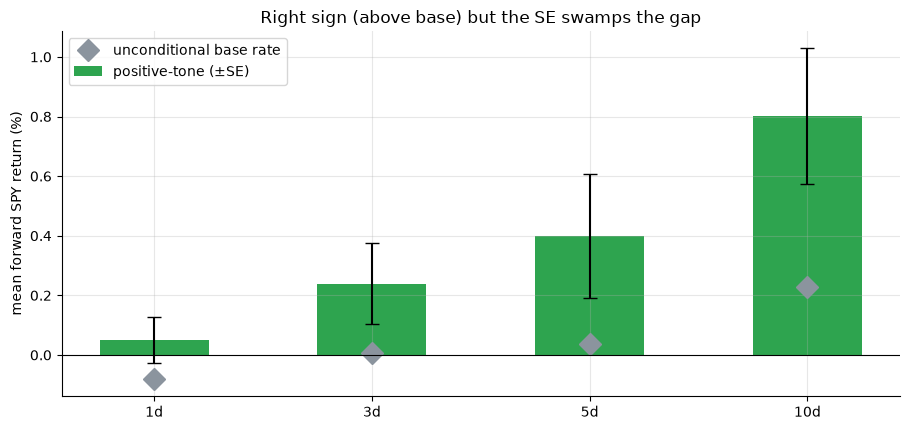

Welch t by horizon: {'1d': 1.13, '3d': 0.95, '5d': 1.16, '10d': 1.44}


In [2]:
hs = [1, 3, 5, 10]
if HAVE_REAL:
    pm, bm, ts, ses = [], [], [], []
    for h in hs:
        s = st.summarize(REL, SPY, h); pm.append(s['pos_mean']); bm.append(s['base_mean']); ts.append(s['t'])
        p,_n,_a = st.split_returns(REL, SPY, h); ses.append(p.std(ddof=1)/np.sqrt(len(p)))
else:
    pm = [R['h1'][2]/100, R['h3'][2]/100, R['h5'][2]/100, R['h10'][2]/100]
    bm = [R['h1'][4]/100, R['h3'][4]/100, R['h5'][4]/100, R['h10'][4]/100]
    ts = [R['h1'][7], R['h3'][7], R['h5'][7], R['h10'][7]]; ses = [.0018,.003,.0035,.0055]
x = np.arange(len(hs))
fig, ax = plt.subplots(figsize=(9.2, 4.4))
ax.bar(x, [p*100 for p in pm], yerr=[e*100 for e in ses], capsize=5, color=GREEN, width=.5, label='positive-tone (±SE)')
ax.plot(x, [b*100 for b in bm], 'D', ms=11, c=GREY, label='unconditional base rate')
ax.set_xticks(x); ax.set_xticklabels([f'{h}d' for h in hs]); ax.axhline(0, c='k', lw=.8)
ax.set_ylabel('mean forward SPY return (%)')
ax.set_title('Right sign (above base) but the SE swamps the gap'); ax.legend()
plt.tight_layout(); plt.show()
print('Welch t by horizon:', {f'{h}d': round(t,2) for h,t in zip(hs,ts)})

> 💡 In plain words: at 5d the positive-tone mean is **+0.40%** vs base **+0.04%** — a ~0.36-point gap at **t = 1.16** (not significant); the best any horizon manages is **t = 1.44** (10d, placebo p = 0.06). H₁ is **directionally supported, statistically not** — the right sign living inside its error bar.

### 4b · The dose-response — does *more* tone buy *more* drift?

OLS $r_H = a + b\,s + \varepsilon$; the bars are the Newey-West (HAC) *t* on the slope $b$. A real dose-response would clear $|t|=2$ *and persist* across horizons.

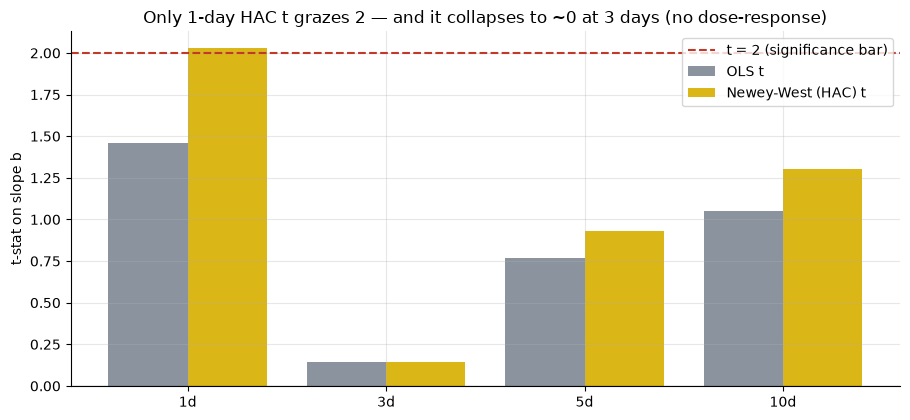

HAC t by horizon: {'1d': 2.03, '3d': 0.14, '5d': 0.93, '10d': 1.3}


In [3]:
hs = [1, 3, 5, 10]
if HAVE_REAL:
    thac = [st.tone_drift_regression(REL, SPY, h)['t_hac'] for h in hs]
    tols = [st.tone_drift_regression(REL, SPY, h)['t_ols'] for h in hs]
else:
    thac = [R['reg'][h][2] for h in hs]; tols = [R['reg'][h][1] for h in hs]
x = np.arange(len(hs))
fig, ax = plt.subplots(figsize=(9.2, 4.3))
ax.bar(x-.2, tols, .4, color=GREY, label='OLS t')
ax.bar(x+.2, thac, .4, color=AMBER, label='Newey-West (HAC) t')
ax.axhline(2, ls='--', c=RED, label='t = 2 (significance bar)'); ax.axhline(0, c='k', lw=.8)
ax.set_xticks(x); ax.set_xticklabels([f'{h}d' for h in hs]); ax.set_ylabel('t-stat on slope b')
ax.set_title('Only 1-day HAC t grazes 2 — and it collapses to ~0 at 3 days (no dose-response)')
ax.legend(); plt.tight_layout(); plt.show()
print('HAC t by horizon:', {f'{h}d': round(t,2) for h,t in zip(hs,thac)})

> 💡 In plain words: the slope's HAC *t* touches **2.03** at 1 day — then **falls to 0.14** at 3 days and never recovers. Because the releases are ~monthly, the multi-day windows barely overlap, so the OLS and HAC *t* agree there's no signal; the lone 1-day HAC blip is an isolated crossing among four horizons (the kind multiple looks manufacture), **not** a dose-response. **H₂ rejected.**

### 4c · The decisive confound — regime, not lead

Positive tone isn't sprinkled randomly through time; it clusters in expansions. Remove the single dominant regime (2020) and ask what's left.

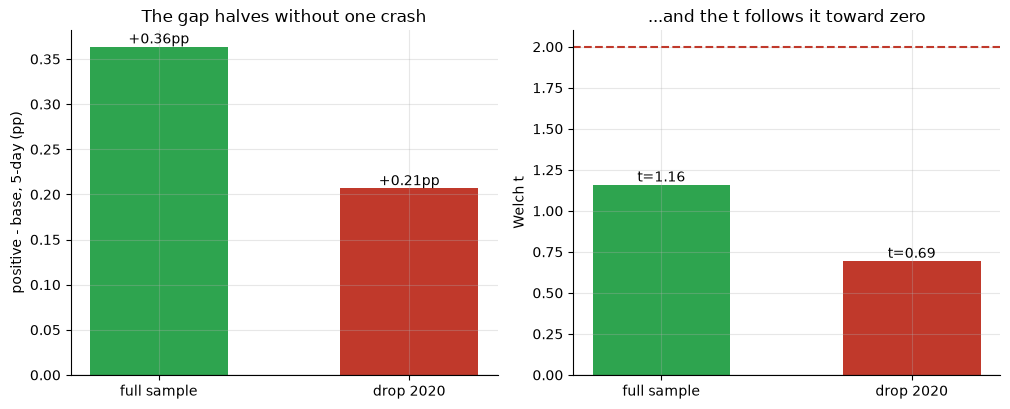

gap full +0.36pp (t 1.16) -> ex-2020 +0.21pp (t 0.69)


In [4]:
if HAVE_REAL:
    full = st.summarize(REL, SPY, 5)
    rel2 = REL[(REL.index < '2020-01-01') | (REL.index >= '2021-01-01')]
    exc = st.summarize(rel2, SPY, 5)
    gaps = [(full['pos_mean']-full['base_mean'])*100, (exc['pos_mean']-exc['base_mean'])*100]
    tvals = [full['t'], exc['t']]
else:
    gaps = [R['h5'][2]-R['h5'][4], R['robust'][2][2]-R['robust'][2][3]]
    tvals = [R['h5'][7], R['robust'][2][4]]
fig, (a1, a2) = plt.subplots(1, 2, figsize=(10.2, 4.2))
labels = ['full sample', 'drop 2020']
a1.bar(labels, gaps, color=[GREEN, RED], width=.55)
for i,v in enumerate(gaps): a1.annotate(f'{v:+.2f}pp',(i,v),ha='center',va='bottom')
a1.axhline(0, c='k', lw=.8); a1.set_ylabel('positive - base, 5-day (pp)'); a1.set_title('The gap halves without one crash')
a2.bar(labels, tvals, color=[GREEN, RED], width=.55)
for i,v in enumerate(tvals): a2.annotate(f't={v:.2f}',(i,v),ha='center',va='bottom')
a2.axhline(2, ls='--', c=RED); a2.axhline(0, c='k', lw=.8); a2.set_ylabel('Welch t'); a2.set_title('...and the t follows it toward zero')
plt.tight_layout(); plt.show()
print(f'gap full {gaps[0]:+.2f}pp (t {tvals[0]:.2f}) -> ex-2020 {gaps[1]:+.2f}pp (t {tvals[1]:.2f})')

> 💡 In plain words: the positive-minus-base gap falls from **+0.36pp** (t 1.16) to **+0.21pp** (t 0.69) once 2020 is dropped, and corr(tone, *prior* 5-day return) is **-0.24** — the tone tracks recent conditions, it doesn't lead them. **H₃ rejected.** What looked like a signal was the equity risk premium, sampled on the Beige-Book calendar.

### 4d · Tradability — the event overlay captures almost nothing

Long SPY for the 5-day post-release window on each positive book, 1 bp one-way (round-trip 2 bp), else flat. Annualised net vs buy-and-hold, plus the per-event Sharpe.

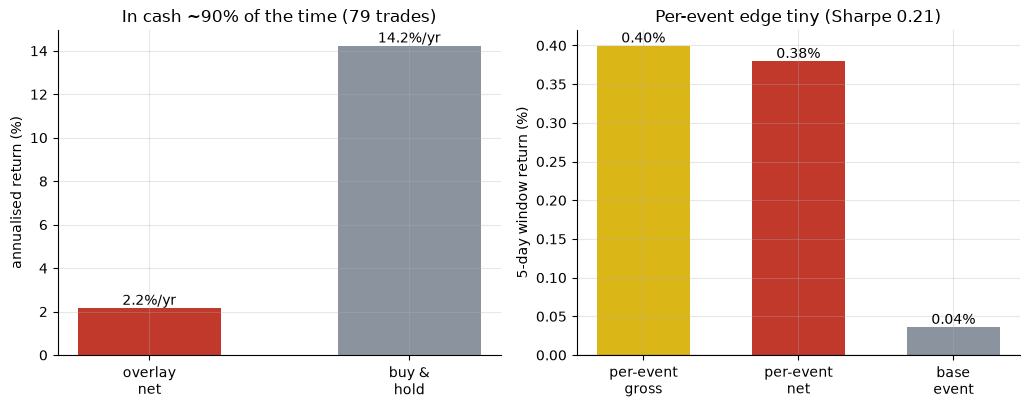

overlay net 2.2%/yr vs buy-hold 14.2%/yr; per-event net 0.38% (Sharpe 0.21)


In [5]:
if HAVE_REAL:
    o = st.event_overlay(REL, SPY, h=5, cost_bps=1.0)
    ann_net, bh, esh, ntr = o['ann_net']*100, o['bh_ann']*100, o['event_sharpe'], o['n_trades']
    peg, pen, beb = o['per_event_gross']*100, o['per_event_net']*100, o['base_event']*100
else:
    ann_net, bh, esh, ntr = R['overlay'][6], R['overlay'][7], R['overlay'][3], R['overlay'][4]
    peg, pen, beb = R['overlay'][0], R['overlay'][1], R['overlay'][2]
fig, (a1, a2) = plt.subplots(1, 2, figsize=(10.4, 4.2))
a1.bar(['overlay\nnet', 'buy &\nhold'], [ann_net, bh], color=[RED, GREY], width=.55)
for i,v in enumerate([ann_net,bh]): a1.annotate(f'{v:.1f}%/yr',(i,v),ha='center',va='bottom')
a1.set_ylabel('annualised return (%)'); a1.set_title(f'In cash ~90% of the time ({ntr} trades)')
a2.bar(['per-event\ngross', 'per-event\nnet', 'base\nevent'], [peg, pen, beb], color=[AMBER, RED, GREY], width=.6)
for i,v in enumerate([peg,pen,beb]): a2.annotate(f'{v:.2f}%',(i,v),ha='center',va='bottom')
a2.axhline(0, c='k', lw=.8); a2.set_ylabel('5-day window return (%)'); a2.set_title(f'Per-event edge tiny (Sharpe {esh:.2f})')
plt.tight_layout(); plt.show()
print(f'overlay net {ann_net:.1f}%/yr vs buy-hold {bh:.1f}%/yr; per-event net {pen:.2f}% (Sharpe {esh:.2f})')

> 💡 In plain words: the overlay's per-event window is mildly positive (**+0.38%** net, Sharpe **0.21**), but firing only ~6×/yr for 5 days it's out of the market ~90% of the time, so it annualises to **+2.2%/yr** against buy-hold's **+14.2%**. Costs aren't even the issue — there's simply almost no exposure to a barely-positive, insignificant edge. `MIRAGE`.

### 4e · Faithful-engine control — we know the truth here

A deterministic series with a *planted* link (a positive-tone release at $t$ lifts the 5-day post-release drift by `edge`$\times$tone). With `edge=0` the test must stay flat; with a large `edge` it must light up — proving the null on the real proxy isn't a broken pipeline.

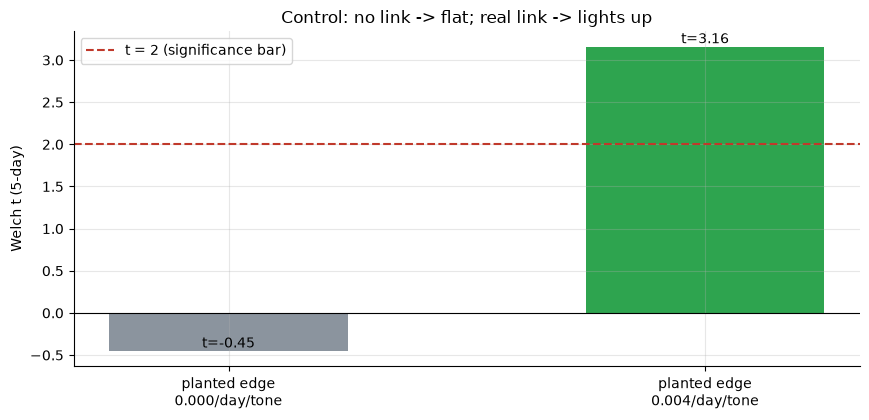

planted 0.000: n_pos=62 pos5d=0.18% base5d=0.34% Welch_t=-0.45 HAC_t=-1.43
planted 0.004: n_pos=62 pos5d=1.81% base5d=0.52% Welch_t=3.16 HAC_t=7.84


In [6]:
res = []
for edge in (0.0, 0.004):
    srel, sspy = data.synthetic(n_years=14, edge=edge, seed=754)
    s = st.summarize(srel, sspy, 5); r = st.tone_drift_regression(srel, sspy, 5)
    res.append((edge, s['n_pos'], s['pos_mean']*100, s['base_mean']*100, s['t'], r['t_hac']))
fig, ax = plt.subplots(figsize=(8.8, 4.3))
labels = [f'planted edge\n{e:.3f}/day/tone' for e,_,_,_,_,_ in res]
tvals = [r[4] for r in res]
ax.bar(labels, tvals, color=[GREY, GREEN], width=.5)
ax.axhline(2, ls='--', c=RED, label='t = 2 (significance bar)'); ax.axhline(0, c='k', lw=.8)
for i,t in enumerate(tvals): ax.annotate(f't={t:.2f}',(i,t),ha='center',va='bottom')
ax.set_ylabel('Welch t (5-day)'); ax.set_title('Control: no link -> flat; real link -> lights up'); ax.legend()
plt.tight_layout(); plt.show()
for e,k,p,b,t,th in res: print(f'planted {e:.3f}: n_pos={k} pos5d={p:.2f}% base5d={b:.2f}% Welch_t={t:.2f} HAC_t={th:.2f}')

> 💡 In plain words: with **no** planted link the control sits at **Welch t = -0.45** (HAC -1.43) — no false positive; a large planted link drives **Welch t = 3.16** (HAC 7.84). The machinery is honest — so the real-proxy null (best t ~1.4) is a *genuine* absent-or-tiny edge through this keyhole, not a measurement failure. The engine *can* bank a real tone→drift link; the proxy tape just doesn't carry a tradable one.

## 5 · The verdict

- **Signal `NONE`** — positive-tone forward drift is the right sign at every horizon (5-day **+0.40%** vs base **+0.04%**) but **no horizon clears t ≥ 2** (best Welch **t = 1.44**, placebo **p = 0.06**); the dose-response HAC *t* clears 2 at only the 1-day horizon and collapses at 3 days. Literature supports Beige-Book *economic* content, but this tape can't certify an *equity* signal.
- **Tradability `MIRAGE`** — the event overlay returns **+2.2%/yr** net vs buy-hold **+14.2%/yr**, in cash ~90% of the time. Almost nothing to harvest, before microstructure even bites.
- **Anecdote leads the tape? `NOT SUPPORTED`** — ex-2020 the gap falls to **+0.21pp** (t **0.69**) and corr(tone, *prior* return) = **-0.24**. The tone **describes** a cycle the equity market already priced; it doesn't lead the price. *Proxy caveat: the tone is a labelled reconstruction — the real-text scrape is the honest re-test, and the null here is robust to the regime confound the proxy can't manufacture away.*

## 6 · Could you trade it? — why even a real tilt wouldn't deploy

Grant the lore a genuine few-hundredths tilt. The plumbing still defeats it. The Beige Book prints ~**2 p.m. ET**; by the 4 p.m. close the entire buy-side has parsed every district's adjectives, so any drift is **intraday and same-day** — before the conservative next-close entry a no-look-ahead rule can use. It also lands **~2 weeks before the FOMC decision**, the event that actually repositions rates books, making the Beige Book a pre-game whose information is dominated by what the meeting will say. And the overlay's structural problem is exposure: firing 5 days at a time on ~8 scheduled releases, it is out of the market **~90%** of the year, so even a real per-event edge can't compound into anything. A scheduled, exhaustively-parsed, pre-FOMC government text is the *least* likely home for un-arbitraged equity drift — and the tape agrees.

## 7 · Going further

- **Kill the proxy.** Scrape the Fed's full Beige-Book archive, count the real Loughran-McDonald positive/negative terms per release, and rerun this exact engine — the event study, the HAC regression, the regime test and the overlay are all proxy-agnostic.
- **Siblings on hard data.** [Study 387 — Economic-Surprise-Index](../387-economic-surprise-index/) and [Study 385 — Jobless-Claims-Momentum](../385-jobless-claims-momentum/): does any macro tell lead equities, numbers instead of adjectives?
- **Fed-sensitive targets.** Re-point the drift at the **2-year note**, the **dollar**, or rate-sensitive sectors, and test the tone *change* (book-to-book) rather than the level — a real Beige-Book effect, if it exists, most plausibly lives in rates, not SPY.

*The reproducible core is offline and deterministic; the tone input is an explicit labelled proxy. Methods and sources: [`docs/references.md`](../docs/references.md); frozen numbers: [`docs/results.md`](../docs/results.md).*